<a href="https://colab.research.google.com/github/lazarosgogos/ML-exercises/blob/main/ML_Project_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# -- DATA ENGINEERING --

## Load libraries

In [20]:
import pandas as pd
import numpy as np
!pip --quiet install ydata-profiling
from ydata_profiling import ProfileReport
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_fscore_support
from sklearn.tree import plot_tree
from matplotlib import pyplot as plt
import matplotlib
from tensorflow.keras.datasets import mnist
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import umap
from sklearn.neighbors import KNeighborsClassifier as KNC

## Fetch dataset

In [ ]:
!gdown 1554FRLDBIb04_hAElnVVpX_Vjdtar5cz -O bankloan.csv

Downloading...
From: https://drive.google.com/uc?id=1554FRLDBIb04_hAElnVVpX_Vjdtar5cz
To: /content/bankloan.csv
100% 63.3M/63.3M [00:03<00:00, 16.6MB/s]


In [ ]:
df = pd.read_csv('bankloan.csv')
df.describe()

,Row ID,id,member_id,loan_amnt,funded_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,annual_inc_joint,dti_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,Unnamed: 50,36months,60months
count,368.000000,2.129990e+05,2.129990e+05,212999.000000,212999.000000,212999.000000,212999.000000,2.129990e+05,212999.000000,212999.000000,212999.000000,109628.000000,212999.000000,212999.000000,2.129990e+05,212917.000000,212999.000000,212999.000000,212999.000000,212999.000000,212999.000000,212999.000000,212999.000000,212999.000000,212999.000000,212999.000000,62365.000000,441.000000,439.000000,212999.000000,212999.000000,2.129990e+05,2.129990e+05,0.0,511.000000,511.000000
mean,184.500000,6.103515e+07,6.515927e+07,15257.965530,15257.965530,12.401658,440.842921,7.780071e+04,19.360817,0.347462,0.564801,34.169491,11.974883,0.234372,1.798871e+04,53.343256,25.314612,14181.628878,1364.078114,891.404111,468.152420,0.047166,4.474419,0.715744,436.159535,0.021643,45.468356,107574.096327,18.320114,0.005718,261.951652,1.416537e+05,3.444425e+04,NaN,0.622309,0.377691
std,106.376689,4.734904e+06,5.215173e+06,8611.713377,8611.713377,4.249365,245.858646,8.188065e+04,31.925871,0.921209,0.861729,22.031958,5.663604,0.662439,2.459627e+04,23.903506,12.035225,8347.954524,1301.876816,996.927204,479.895277,1.230610,156.642555,22.893806,450.680782,0.161511,22.645675,47921.057382,7.230012,0.081045,2215.188372,1.568766e+05,3.531827e+04,NaN,0.485285,0.485285
min,1.000000,5.670500e+04,7.082500e+04,1000.000000,1000.000000,5.320000,30.120000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17950.000000,3.050000,0.000000,0.000000,0.000000e+00,0.000000e+00,NaN,0.000000,0.000000
25%,92.750000,5.783411e+07,6.158651e+07,8500.000000,8500.000000,9.170000,262.230000,4.700000e+04,12.660000,0.000000,0.000000,15.000000,8.000000,0.000000,6.545000e+03,35.500000,17.000000,7653.720000,507.465000,328.240000,142.920000,0.000000,0.000000,0.000000,250.000000,0.000000,28.000000,75001.000000,13.185000,0.000000,0.000000,3.143300e+04,1.460000e+04,NaN,0.000000,0.000000
50%,184.500000,6.137900e+07,6.549753e+07,14000.000000,14000.000000,12.290000,382.870000,6.500000e+04,18.720000,0.000000,0.000000,31.000000,11.000000,0.000000,1.205900e+04,53.500000,24.000000,12823.900000,1029.320000,656.890000,310.890000,0.000000,0.000000,0.000000,375.430000,0.000000,45.000000,100000.000000,17.750000,0.000000,0.000000,8.138600e+04,2.510000e+04,NaN,1.000000,0.000000
75%,276.250000,6.503778e+07,6.956436e+07,20000.000000,20000.000000,14.650000,578.790000,9.250000e+04,25.520000,0.000000,1.000000,50.000000,15.000000,0.000000,2.158800e+04,71.700000,32.000000,19494.530000,1859.630000,1165.990000,631.195000,0.000000,0.000000,0.000000,572.600000,0.000000,63.000000,131000.000000,22.650000,0.000000,0.000000,2.097080e+05,4.260000e+04,NaN,1.000000,1.000000
max,368.000000,6.861687e+07,7.351969e+07,35000.000000,35000.000000,28.990000,1445.460000,9.000000e+06,9999.000000,30.000000,5.000000,171.000000,82.000000,86.000000,1.630818e+06,193.000000,169.000000,49372.860000,35773.700000,34963.280000,4722.360000,124.760000,26308.470000,2037.493800,35330.490000,7.000000,171.000000,410000.000000,43.860000,5.000000,380757.000000,4.127799e+06,1.641300e+06,NaN,1.000000,1.000000


In [ ]:
df.head()

,Row ID,id,member_id,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,title,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,application_type,annual_inc_joint,dti_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,Unnamed: 50,36months,60months
0,1.0,60516983,64537751,20000,20000,36 months,12.29,667.06,C,C1,Accounting Clerk,1 year,OWN,65000.0,Source Verified,15-Sep,Charged Off,debt_consolidation,Debt consolidation,20.72,0,Sep-00,1,NaN,25,0,31578,77.0,42,w,0.0,0.00,0.00,0.00,0.0,0.0,0.0,NaN,0.00,NaN,16-Jan,0,NaN,INDIVIDUAL,NaN,NaN,0,0,52303,41000,NaN,1.0,0.0
1,2.0,60187139,64163931,11000,11000,36 months,12.69,369.00,C,C2,Accounts Payable Lead,7 years,MORTGAGE,40000.0,Source Verified,15-Sep,Charged Off,debt_consolidation,Debt consolidation,24.57,0,2-Sep,0,36.0,13,1,5084,38.8,41,w,0.0,10043.49,9942.67,100.81,0.0,0.0,0.0,15-Oct,10059.00,NaN,16-Jan,0,79.0,INDIVIDUAL,NaN,NaN,0,332,175731,13100,NaN,1.0,0.0
2,3.0,60356453,64333218,7000,7000,36 months,9.99,225.84,B,B3,Nurse,6 years,MORTGAGE,32000.0,Source Verified,15-Sep,Charged Off,debt_consolidation,Debt consolidation,32.41,0,6-Feb,1,NaN,18,0,12070,74.0,36,f,0.0,221.96,167.56,54.40,0.0,0.0,0.0,15-Oct,225.84,NaN,16-Jan,0,NaN,INDIVIDUAL,NaN,NaN,0,0,202012,16300,NaN,1.0,0.0
3,4.0,59955769,63900496,10000,10000,36 months,10.99,327.34,B,B4,Service Manager,10+ years,MORTGAGE,48000.0,Source Verified,15-Sep,Charged Off,credit_card,Credit card refinancing,30.98,0,Oct-99,2,NaN,18,0,22950,66.0,41,f,0.0,315.13,235.76,79.37,0.0,0.0,0.0,15-Oct,327.34,NaN,16-Jan,0,NaN,INDIVIDUAL,NaN,NaN,0,0,108235,34750,NaN,1.0,0.0
4,5.0,58703693,62544456,9550,9550,36 months,19.99,354.87,E,E4,NaN,NaN,RENT,32376.0,Verified,15-Sep,Charged Off,debt_consolidation,Debt consolidation,32.54,0,Nov-99,3,69.0,9,0,4172,29.6,26,w,0.0,333.66,195.78,137.88,0.0,0.0,0.0,15-Oct,354.87,NaN,16-Jan,0,69.0,INDIVIDUAL,NaN,NaN,0,0,45492,14100,NaN,1.0,0.0


In [ ]:
# profile = ProfileReport(df, title='Bankloan profiling report')
# profile

# Q2 - DATA PROCESSING AND VISUALIZATION

## Q2.1 - What is the maximum, mean and minimum value of `loan_amnt`?
Based on the ydata-profiler output, the minimum value is 1000, the mean is 15257.965530 and the maximum value is 35000

## Q2.2 - Which columns can be removed from our dataframe?
We can remove all the ID columns, as they provide no useful information for our model. We can remove columns that are full of NaN values. We may remove highly correlated columns as well (e.g. purpose and title). We can also remove columns of which all rows consist of the same value. Finally we can impute some of the missing values.

In [ ]:
# remove unnecessary columns
clean_df = df.drop(columns=['Row ID', 'id', 'member_id', 'loan_status',
                            'total_rec_late_fee',
                            'funded_amnt', 'purpose',
                            'recoveries', 'collection_recovery_fee',
                            'collections_12_mths_ex_med', 'annual_inc_joint',
                            'dti_joint', 'acc_now_delinq',
                            'tot_coll_amt', 'Unnamed: 50',
                            '36months', '60months', 'last_pymnt_d',
                            'next_pymnt_d', 'emp_title'])
# fill any missing value left with 0
# clean_df['emp_title'] = clean_df['emp_title'].replace(np.nan, 'Other')
clean_df['emp_length'] = clean_df['emp_length'].replace(np.nan, '< 1 year')
clean_df['title'] = clean_df['title'].replace(np.nan, 'Other')

unique_dates = clean_df['last_credit_pull_d'].dropna().unique()
nan_mask = clean_df['last_credit_pull_d'].isnull()
clean_df.loc[nan_mask, 'last_credit_pull_d'] = np.random.choice(unique_dates,
                                                                size=nan_mask.sum())
# clean info that led to grade assessment
clean_df = clean_df.drop(columns=[
    'issue_d', 'delinq_2yrs', 'earliest_cr_line',
    'mths_since_last_delinq', 'out_prncp', 'total_pymnt',
    'total_rec_prncp', 'total_rec_int',
    'last_credit_pull_d', 'mths_since_last_major_derog',
    'last_pymnt_amnt', 'int_rate'
])

clean_df.replace(np.nan, 0, inplace=True)

In [ ]:
pd.set_option('display.max_columns', None)
clean_df

,loan_amnt,term,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,title,dti,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,tot_cur_bal,total_rev_hi_lim
0,20000,36 months,667.06,C,C1,1 year,OWN,65000.00,Source Verified,Debt consolidation,20.72,1,25,0,31578,77.0,42,w,INDIVIDUAL,52303,41000
1,11000,36 months,369.00,C,C2,7 years,MORTGAGE,40000.00,Source Verified,Debt consolidation,24.57,0,13,1,5084,38.8,41,w,INDIVIDUAL,175731,13100
2,7000,36 months,225.84,B,B3,6 years,MORTGAGE,32000.00,Source Verified,Debt consolidation,32.41,1,18,0,12070,74.0,36,f,INDIVIDUAL,202012,16300
3,10000,36 months,327.34,B,B4,10+ years,MORTGAGE,48000.00,Source Verified,Credit card refinancing,30.98,2,18,0,22950,66.0,41,f,INDIVIDUAL,108235,34750
4,9550,36 months,354.87,E,E4,< 1 year,RENT,32376.00,Verified,Debt consolidation,32.54,3,9,0,4172,29.6,26,w,INDIVIDUAL,45492,14100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212994,20000,36 months,677.07,C,C3,5 years,RENT,120000.00,Source Verified,Debt consolidation,9.04,0,6,0,7,0.1,34,w,INDIVIDUAL,21474,5400
212995,6000,36 months,197.95,B,B5,10+ years,RENT,25000.00,Not Verified,Credit card refinancing,2.21,2,3,1,2176,52.0,11,w,INDIVIDUAL,2176,4200
212996,18000,60 months,468.82,E,E3,< 1 year,RENT,120000.00,Source Verified,Debt consolidation,7.76,1,4,0,3229,21.1,5,w,INDIVIDUAL,8414,15300
212997,7050,36 months,246.51,D,D1,< 1 year,MORTGAGE,18614.27,Verified,Other,21.53,0,12,0,10256,38.3,25,w,INDIVIDUAL,159660,26800


## Q2.3 - Perform other preprocessing methods of your choice
We will perform z-score normalization on numerical columns. We could also convert columns with categorical values to encoded integers.

In [ ]:
numerical_cols = clean_df.select_dtypes(include=[np.number]).columns
zscore_df = clean_df.copy()
zscore_df[numerical_cols] = zscore_df[numerical_cols].apply(zscore)
zscore_df

,loan_amnt,term,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,title,dti,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,tot_cur_bal,total_rev_hi_lim
0,0.550651,36 months,0.920112,C,C1,1 year,OWN,-0.156334,Source Verified,Debt consolidation,0.042573,0.505032,2.299798,-0.353802,0.552495,0.989781,1.386383,w,INDIVIDUAL,-0.569562,0.185620
1,-0.494440,36 months,-0.292213,C,C2,7 years,MORTGAGE,-0.461657,Source Verified,Debt consolidation,0.163165,-0.655429,0.181001,1.155774,-0.524662,-0.607093,1.303293,w,INDIVIDUAL,0.217224,-0.604342
2,-0.958925,36 months,-0.874500,B,B3,6 years,MORTGAGE,-0.559361,Source Verified,Debt consolidation,0.408735,0.505032,1.063833,-0.353802,-0.240635,0.864372,0.887845,f,INDIVIDUAL,0.384751,-0.513737
3,-0.610561,36 months,-0.461660,B,B4,10+ years,MORTGAGE,-0.363954,Source Verified,Credit card refinancing,0.363943,1.665492,1.063833,-0.353802,0.201710,0.529948,1.303293,f,INDIVIDUAL,-0.213026,0.008657
4,-0.662816,36 months,-0.349685,E,E4,< 1 year,RENT,-0.554769,Verified,Debt consolidation,0.412807,2.825953,-0.525264,-0.353802,-0.561741,-0.991680,0.056949,w,INDIVIDUAL,-0.612978,-0.576028
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212994,0.550651,36 months,0.960827,C,C3,5 years,RENT,0.515377,Source Verified,Debt consolidation,-0.323275,-0.655429,-1.054964,-0.353802,-0.731076,-2.224868,0.721666,w,INDIVIDUAL,-0.766080,-0.822360
212995,-1.075046,36 months,-0.987940,B,B5,10+ years,RENT,-0.644851,Not Verified,Credit card refinancing,-0.537209,1.665492,-1.584663,1.155774,-0.642892,-0.055294,-1.189396,w,INDIVIDUAL,-0.889094,-0.856336
212996,0.318408,60 months,0.113794,E,E3,< 1 year,RENT,0.515377,Source Verified,Debt consolidation,-0.363368,0.505032,-1.408097,-0.353802,-0.600080,-1.347005,-1.687933,w,INDIVIDUAL,-0.849330,-0.542051
212997,-0.953119,36 months,-0.790427,D,D1,< 1 year,MORTGAGE,-0.722840,Verified,Other,0.067945,-0.655429,0.004435,-0.353802,-0.314386,-0.627994,-0.026141,w,INDIVIDUAL,0.114780,-0.216439


## Q2.4 - Create a `target` column

In [ ]:
zscore_df.sub_grade.value_counts().sort_index()

,count
sub_grade,
A1,7401
A2,5773
A3,5397
A4,7151
A5,11150
B1,12376
B2,12042
B3,13159
B4,12806


In [ ]:
def make_targets(row):
  if row['sub_grade'] in ['A1', 'A2', 'A3','A4', 'A5', 'B1', 'B2']:
    return 1
  return 0

zscore_df['target'] = zscore_df.apply(make_targets,axis=1)
zscore_df[['sub_grade', 'target']]

,sub_grade,target
0,C1,0
1,C2,0
2,B3,0
3,B4,0
4,E4,0
...,...,...
212994,C3,0
212995,B5,0
212996,E3,0
212997,D1,0


## Q2.5 - Find a range of loan amounts with a 15% of approval

In [ ]:
bins = np.linspace(clean_df['loan_amnt'].min(),
                   clean_df['loan_amnt'].max(), 6) # X bins between 1000 and 35000
clean_df['target'] = zscore_df['target'].copy() # copy the colunn
clean_df['amnt_bin'] = pd.cut(clean_df['loan_amnt'], bins=bins, include_lowest=True)

rates = clean_df.groupby('amnt_bin', observed=True)['target'].mean()

target_rate = .15
closest = rates.iloc[(rates-target_rate).abs().argsort()[:5]]
print(closest)

amnt_bin
(28200.0, 35000.0]    0.146917
(14600.0, 21400.0]    0.288837
(999.999, 7800.0]     0.290400
(7800.0, 14600.0]     0.315142
(21400.0, 28200.0]    0.317788
Name: target, dtype: float64


# Q3 - CLASSIFICATION

## Q3.1 - Normalize input and create the dataset
We went with zscore normalization across all numerical columns, since it handles outliers better, and they are centered around 0, avoiding weight number explosions of our model weights.

In [ ]:
final_df = zscore_df.drop(columns=['grade', 'sub_grade', ])
# final_df['term'] = final_df.term.astype('category')
for col in final_df.columns:
    if final_df[col].dtype == 'object':
        final_df[col] = final_df[col].astype('category').cat.codes

final_df#.head()

,loan_amnt,term,installment,emp_length,home_ownership,annual_inc,verification_status,title,dti,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,tot_cur_bal,total_rev_hi_lim,target
0,0.550651,0,0.920112,0,2,-0.156334,1,3,0.042573,0.505032,2.299798,-0.353802,0.552495,0.989781,1.386383,1,0,-0.569562,0.185620,0
1,-0.494440,0,-0.292213,7,1,-0.461657,1,3,0.163165,-0.655429,0.181001,1.155774,-0.524662,-0.607093,1.303293,1,0,0.217224,-0.604342,0
2,-0.958925,0,-0.874500,6,1,-0.559361,1,3,0.408735,0.505032,1.063833,-0.353802,-0.240635,0.864372,0.887845,0,0,0.384751,-0.513737,0
3,-0.610561,0,-0.461660,1,1,-0.363954,1,2,0.363943,1.665492,1.063833,-0.353802,0.201710,0.529948,1.303293,0,0,-0.213026,0.008657,0
4,-0.662816,0,-0.349685,10,3,-0.554769,2,3,0.412807,2.825953,-0.525264,-0.353802,-0.561741,-0.991680,0.056949,1,0,-0.612978,-0.576028,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212994,0.550651,0,0.960827,5,3,0.515377,1,3,-0.323275,-0.655429,-1.054964,-0.353802,-0.731076,-2.224868,0.721666,1,0,-0.766080,-0.822360,0
212995,-1.075046,0,-0.987940,1,3,-0.644851,0,2,-0.537209,1.665492,-1.584663,1.155774,-0.642892,-0.055294,-1.189396,1,0,-0.889094,-0.856336,0
212996,0.318408,1,0.113794,10,3,0.515377,1,3,-0.363368,0.505032,-1.408097,-0.353802,-0.600080,-1.347005,-1.687933,1,0,-0.849330,-0.542051,0
212997,-0.953119,0,-0.790427,10,1,-0.722840,2,10,0.067945,-0.655429,0.004435,-0.353802,-0.314386,-0.627994,-0.026141,1,0,0.114780,-0.216439,0


## Q3.2 - Use a stratified 70/30 train/test split.

In [ ]:
X = np.array(final_df.drop(columns=['target']))
y = np.array(final_df['target'])

test_size = .3
seed = 42

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=test_size,
                                                    random_state=seed,
                                                    stratify=y)

## Q3.3 - Perform classification

In [ ]:
# we will use a RandomForest classifier
rfc = RandomForestClassifier()
rfc.fit(x_train, y_train)
rfc.score(x_test, y_test)

0.8634272300469483

In [ ]:
dtc = DecisionTreeClassifier(random_state=seed)
dtc.fit(x_train, y_train)
dtc.score(x_test, y_test)

0.8706885758998435

In [ ]:
# plot_tree(dtc, feature_names=final_df.columns);

The classifiers above either work better without the interest rate or they would benefit from it. Either way, their performance is adequate for now

## Q3.4 - Report on F1 score, Precision and Recall

In [ ]:
preds = rfc.predict(x_test)
precision, recall, f1, support = precision_recall_fscore_support(y_test, preds)
print('Precision for 0 (did not get a loan)')
print(f'  Precision: {precision[0]:.2f}, recall: {recall[0]:.2f}, \
F1-score: {f1[0]:.2f}, support: {support[0]}')
print('Precision for 1 (did get a loan)')
print(f'  Precision: {precision[1]:.2f}, recall: {recall[1]:.2f}, \
F1-score: {f1[1]:.2f}, support: {support[1]}')

Precision for 0 (did not get a loan)
  Precision: 0.88, recall: 0.94, F1-score: 0.91, support: 45513
Precision for 1 (did get a loan)
  Precision: 0.82, recall: 0.67, F1-score: 0.74, support: 18387


### Which metrics are the most important for this usecase?
Based on the fact that this classifier aims to correctly predict whether a bankloan will paid once it is approved, we would strive for the maximal precision, as it is important for the bank to predict with the biggest possible confidence whether a loan will eventually be paid or not.

In [ ]:
# print('Unique values for original categorical columns:')
# for col in zscore_df.select_dtypes(include='object').columns:
#     if col not in ['grade', 'sub_grade', 'earliest_cr_line']: # These were dropped from final_df
#         print(f"\nUnique values for '{col}':")
#         print(zscore_df[col].unique())
# len(zscore_df['emp_title'].unique())

# Q4 - FEATURE IMPORTANCE AND SELECTION

## Q4.1 - The 15 most important features

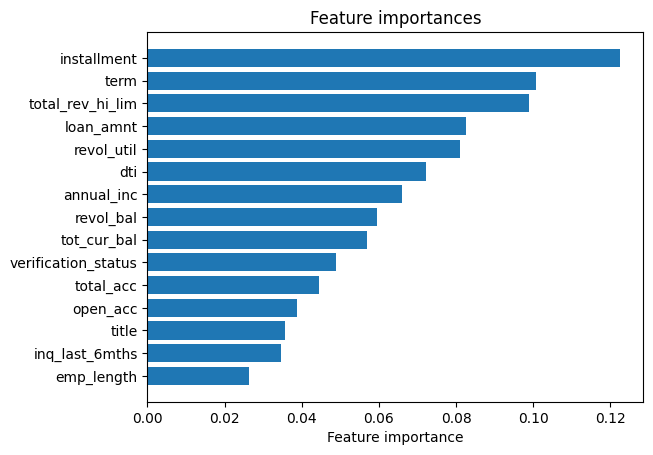

In [ ]:
importances = np.array(rfc.feature_importances_)
index = importances.argsort()[-15:]
feature_names = list(final_df.columns)

plt.barh(np.array(feature_names)[index], importances[index])
plt.xlabel('Feature importance')
plt.title('Feature importances')
plt.show();

## Q4.2 - Correlation matrix

In [ ]:
# Get feature names used for training (excluding the target column)
feature_names_for_training = list(final_df.drop(columns=['target']).columns)

top_15_feature_indices = index
top_15_feature_names = [feature_names_for_training[i] for i in top_15_feature_indices]

# print("Top 15 Most Important Features:")
# print(top_15_feature_names)

# Select these features from the final_df
df_top_features = final_df[top_15_feature_names]
# Calculate the correlation matrix
correlation_matrix = df_top_features.corr()

# print("\nCorrelation Matrix of Top 15 Features:")
# display(correlation_matrix)

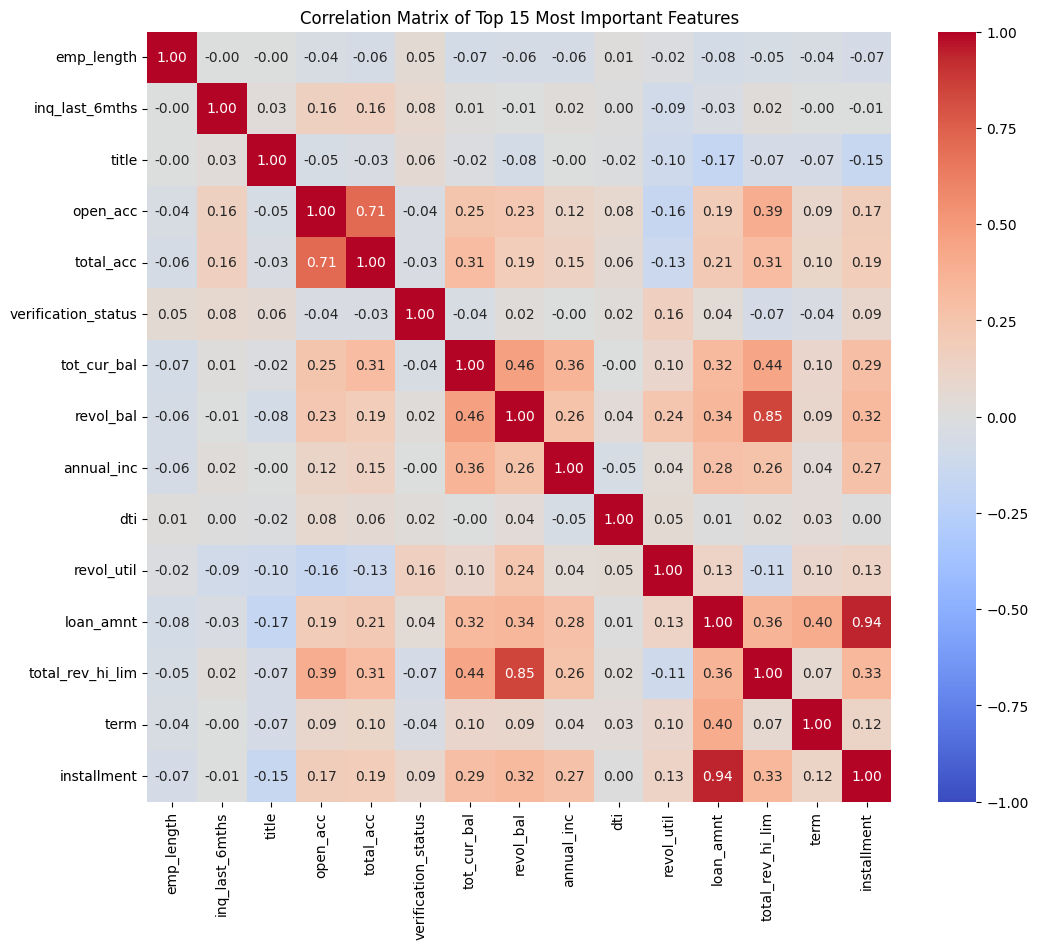

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            vmin=-1, vmax=1)
plt.title('Correlation Matrix of Top 15 Most Important Features')
plt.show()

As shown in the heatmap above, the only high correlation is observed in the loan amount (`loan_amnt`), the revolving balance (`revol_bal`), and the total number of credit lines (`total_acc`).

## Q4.3 - Removing highly correlated features

In [ ]:
removed_df = final_df.drop(columns=['loan_amnt', 'revol_bal', 'total_acc'])
XX = np.array(removed_df.drop(columns=['target']))
yy = np.array(removed_df['target'])

xx_train, xx_test, yy_train, yy_test = train_test_split(XX, yy, test_size=test_size,
                                                    random_state=seed,
                                                    stratify=yy)
rfc2 = RandomForestClassifier()
rfc2.fit(xx_train, yy_train)
y_preds = rfc2.predict(xx_test)
p,r,f,s = precision_recall_fscore_support(yy_test, y_preds)
print('Precision for 0 (did not get a loan)')
print(f'  Precision: {p[0]:.2f}, recall: {r[0]:.2f}, \
F1-score: {f[0]:.2f}, support: {s[0]}')
print('Precision for 1 (did get a loan)')
print(f'  Precision: {p[1]:.2f}, recall: {r[1]:.2f}, \
F1-score: {f[1]:.2f}, support: {s[1]}')

Precision for 0 (did not get a loan)
  Precision: 0.86, recall: 0.92, F1-score: 0.89, support: 45513
Precision for 1 (did get a loan)
  Precision: 0.77, recall: 0.62, F1-score: 0.69, support: 18387


Comparing the results from this classifier to the previous one, and after having removed the correlated features, it seems that the performance of the model has been decreased, meaning that while the features are correlated, they do provide useful information for the model in order to make better predictions.

#Q5 - DIMENSIONALITY REDUCTION

## Q5.1 - Load the MNIST dataset

In [5]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Q5.2 - Standard scale the data

In [13]:
size_train, size_test = len(x_train), len(x_test)
x_train_flat, x_test_flat = x_train.reshape(size_train, -1), x_test.reshape(size_test, -1)
scaler = StandardScaler()
scaler.fit(x_train_flat)
x_train = scaler.transform(x_train_flat)
x_test = scaler.transform(x_test_flat)
seed = 42
Ns = [5, 15, 51, 101]
def assess(x_train, y_train, x_test, y_test):
  accuracies = []
  for n in Ns:
    knc = KNC(n)
    knc.fit(x_train, y_train)
    accuracy = knc.score(x_test, y_test)
    accuracies.append(accuracy)
  return accuracies

##Q5.3 - Perform PCA (Principal Component Analysis)

In [14]:
pca = PCA(300, random_state=seed)
pca.fit(x_train_flat)
x_train_pca = pca.transform(x_train_flat)
x_test_pca = pca.transform(x_test_flat)
pca_accuracies = assess(x_train_pca, y_train, x_test_pca, y_test)
pca_accuracies

[0.9497, 0.9436, 0.9273, 0.9158]

The accuracy decreases from 95% to 91.6%, the more neighbors are taken into account for the classification, meaning a more complex model is to be preferred when PCA is used.

### What would happen had we used `pca.fit_transform` on `x_train` and `x_test` separately, and on a concatenated version of them? What would be the effect and why?
The reason why we only use `fit` on the train data is so that we only take into account the training data, so as not pollute the model with information from the test dataset and get better results than we should actually get.
If we were to use fit on a `x_train + x_test` version of the dataset, we would still infer outputs based on 'unknown' data, thus producing results that would not be representative of reality, and when applied on truly unknown data, we would get worse results.

##Q5.4 - Perform LDA (Linear Discriminant Analysis)

In [18]:
lda = LDA(n_components=2)
lda.fit(x_train_flat, y_train)
x_train_lda = lda.transform(x_train_flat)
x_test_lda = lda.transform(x_test_flat)
lda_accuracies = assess(x_train_lda, y_train, x_test_lda, y_test)
lda_accuracies

[0.523, 0.5587, 0.5644, 0.5718]

The KNN classifier has trouble discerning between inputs when only 2 components are kept from the samples, resulting in a maximum of 57% accuracy with 101 neighbors taken into account. This accuracy is quite low, and cannot be used in real world cases.

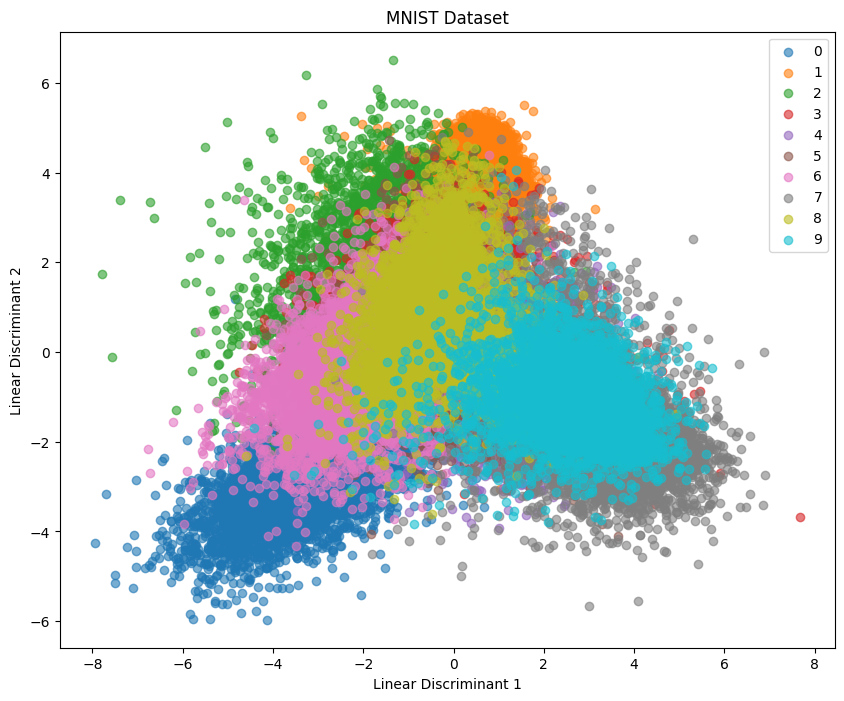

In [33]:
plt.figure(figsize=(10, 8))
colors = plt.get_cmap('tab10')
for i in range(len(np.unique(y_train))):
    plt.scatter(x_train_lda[y_train == i, 0], x_train_lda[y_train == i, 1],
                c=[colors(i)], label=str(i), alpha=0.6)
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.title('MNIST Dataset')
plt.legend()
# plt.grid(True)
plt.show()

### What is observed in this plot?
As shown in the scatter plot above, some of the structural differencies between digits have been maintained, for example the visual difference between a `0` and a `2` is illustrated as the distance between the blue and the green cluster. Similary, for the rest of the clusters, the closer they are, the more the digits look like one another, e.g. digits `9` and `5`, which are quite close to each other.

##Q5.5 - Perform UMAP (Uniform Manifold Approximation and Projection)

In [37]:
reducer = umap.UMAP(n_components=2)
reducer.fit(x_train_flat, y_train)
x_train_reducer = reducer.transform(x_train_flat)
x_test_reducer = reducer.transform(x_test_flat)
reducer_accuracies = assess(x_train_reducer, y_train, x_test_reducer, y_test)
reducer_accuracies

[0.9335, 0.9344, 0.9343, 0.9334]

After performing UMAP, the number of neighbors does not really matter, since even with 2 components, the separation is enough to discern most of the inputs, resulting in a 93% accuracy for all 5, 15, 51, and 101 neighbors.

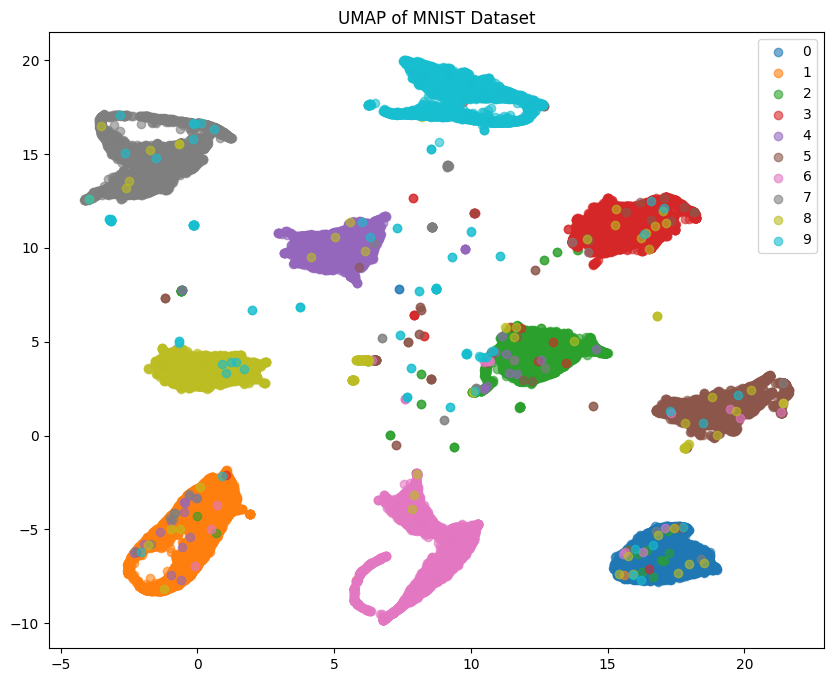

In [40]:
plt.figure(figsize=(10, 8))
colors = plt.get_cmap('tab10')
for i in range(len(np.unique(y_train))):
    plt.scatter(x_train_reducer[y_train == i, 0], x_train_reducer[y_train == i, 1],
                c=[colors(i)], label=str(i), alpha=0.6)
# plt.xlabel('Linear Discriminant 1')
# plt.ylabel('Linear Discriminant 2')
plt.title('UMAP of MNIST Dataset')
plt.legend()
# plt.grid(True)
plt.show()

### How is this plot different from the produced after performing LDA?
As illustrated in the plot above, and by the classification accuracies, UMAP results in much better seperation of the samples. Thus, UMAP appears to be superior to LDA, especially when the number of components is so small.

While there is some overlap between samples, the separation is quite clearer, than the LDA separation.